# 02 – Wrangle
**Assignment:** DLBDSDQDW01 – Data Quality and Data Wrangling  
**Task:** Transform raw MIMIC-IV (hosp + icu schema) toward a CLIF-compatible schema

## Pipeline overview
1. **Cohort definition** → adult first ICU stay ≥ 24 h → `cohort.parquet`  
2. **Lab extraction** → labevents filtered to cohort, first 24 h from ICU `intime`  
3. **DQ cleaning** (following NB01 action items):
   - DQ4 Uniqueness → deduplicate by highest `labevent_id`
   - DQ5 Validity → parse `>/< ` censored strings to boundary numerics
   - DQ2 Consistency → unit standardisation (creatinine µmol/L → mg/dL)
   - DQ3 Accuracy → null physiologically implausible values
4. **Temporal resampling** → aggregate to 4 h bins (6 bins × 24 lab columns)  
5. **Missingness indicators** → `was_measured_<lab>` binary columns  
6. Save `labs_raw.parquet` (cleaned, resampled, **not yet imputed**)  
7. **CLIF schema comparison** → document transformation

**Output files:** `output/cohort.parquet`, `output/labs_raw.parquet`

---
## 0 · Setup

In [1]:
from pathlib import Path
import warnings
import subprocess as sp
import io

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (13, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
})
sns.set_style("whitegrid")

BASE     = Path("physionet.org/files/mimiciv/3.1")
HOSP     = BASE / "hosp"
ICU      = BASE / "icu"
CLIF_DIR = Path("physionet.org/files/mimic-iv-ext-clif/1.1.0")
OUT_DIR  = Path("output")
OUT_DIR.mkdir(exist_ok=True)

# Provenance log – accumulate cleaning step counts for the summary cell
PROV = {}

print("Environment ready.")

Environment ready.


---
## 1 · Load raw tables

In [2]:
admissions = pd.read_csv(
    HOSP / "admissions.csv",
    parse_dates=["admittime", "dischtime", "deathtime"],
)

# patients.csv.gz may have trailing garbage bytes from wget; zcat + BytesIO tolerates this
_r = sp.run(["zcat", str(HOSP / "patients.csv.gz")], capture_output=True)
patients = pd.read_csv(io.BytesIO(_r.stdout))

icustays = pd.read_csv(
    ICU / "icustays.csv.gz",
    parse_dates=["intime", "outtime"],
)

d_labitems = pd.read_csv(HOSP / "d_labitems.csv")

for name, df in [
    ("admissions", admissions),
    ("patients",   patients),
    ("icustays",   icustays),
    ("d_labitems", d_labitems),
]:
    print(f"{name:<12}: {df.shape[0]:>7,} rows × {df.shape[1]} cols")

admissions  : 546,028 rows × 16 cols
patients    : 364,627 rows × 6 cols
icustays    :  94,458 rows × 8 cols
d_labitems  :   1,650 rows × 4 cols


---
## 2 · Cohort definition

**Criteria (from PLAN.md §02):**  
- Adult patient: age at ICU admission ≥ 18 years  
- ICU length of stay ≥ 24 h (1 day; ensures at least one full lab cycle)  
- First ICU stay per patient (avoids repeated-measures bias)

> `anchor_age` in MIMIC-IV is the patient's age at `anchor_year` (not at any specific admission).  
> Age at ICU admission = `anchor_age + (intime.year − anchor_year)`.

In [3]:
# --- 2a: Merge demographics into icustays ---
icustays = icustays.merge(
    patients[["subject_id", "anchor_age", "anchor_year", "gender"]],
    on="subject_id",
    how="left",
)

# Age at ICU admission (approximate — MIMIC shifts dates by ±3 years for privacy)
icustays["age_at_icu"] = (
    icustays["anchor_age"] + (icustays["intime"].dt.year - icustays["anchor_year"])
)

# LOS from icustays.los column is in fractional days (confirmed in MIMIC docs)
print(f"All ICU stays        : {len(icustays):,}")
print(f"  Age < 18           : {(icustays['age_at_icu'] < 18).sum():,}")
print(f"  LOS < 1 day        : {(icustays['los'] < 1.0).sum():,}")

All ICU stays        : 94,458
  Age < 18           : 0
  LOS < 1 day        : 19,615


In [4]:
# --- 2b: Apply filters ---
adult_stays = icustays[
    (icustays["age_at_icu"] >= 18) &
    (icustays["los"]        >= 1.0)
].copy()

# --- 2c: First ICU stay per patient ---
first_stays = (
    adult_stays
    .sort_values(["subject_id", "intime"])
    .groupby("subject_id", as_index=False)
    .first()
)

# --- 2d: Merge mortality label from admissions ---
cohort = first_stays.merge(
    admissions[["hadm_id", "hospital_expire_flag"]],
    on="hadm_id",
    how="left",
)

# Tidy up columns
cohort = cohort[[
    "subject_id", "stay_id", "hadm_id",
    "intime", "outtime", "los",
    "age_at_icu", "gender",
    "first_careunit", "last_careunit",
    "hospital_expire_flag",
]].rename(columns={"age_at_icu": "age", "los": "los_days"})

# A handful of stays have no matching hadm_id in admissions (transfer edge cases) → label 0
cohort["hospital_expire_flag"] = cohort["hospital_expire_flag"].fillna(0).astype(int)

PROV["cohort_n"] = len(cohort)
PROV["mortality_rate"] = cohort["hospital_expire_flag"].mean()

print(f"\nCohort summary")
print(f"  Patients (first adult ICU stay ≥24h) : {len(cohort):,}")
print(f"  Hospital mortality                   : {PROV['mortality_rate']*100:.1f}%")
print(f"\nAge (years):")
print(cohort["age"].describe().round(1).rename(str).to_string())
print(f"\nGender:")
print(cohort["gender"].value_counts().to_string())
print(f"\nTop care units:")
print(cohort["first_careunit"].value_counts().head(6).to_string())


Cohort summary
  Patients (first adult ICU stay ≥24h) : 54,551
  Hospital mortality                   : 10.8%

Age (years):
count   54551.000
mean       65.000
std        16.700
min        18.000
25%        55.000
50%        67.000
75%        77.000
max       103.000

Gender:
gender
M    31056
F    23495

Top care units:
first_careunit
Cardiac Vascular Intensive Care Unit (CVICU)        11008
Medical Intensive Care Unit (MICU)                   9942
Medical/Surgical Intensive Care Unit (MICU/SICU)     7957
Surgical Intensive Care Unit (SICU)                  7458
Trauma SICU (TSICU)                                  6149
Coronary Care Unit (CCU)                             6059


In [5]:
# --- 2e: Save cohort ---
cohort.to_parquet(OUT_DIR / "cohort.parquet", index=False)
print(f"Saved: output/cohort.parquet  ({len(cohort):,} rows × {cohort.shape[1]} cols)")
print(cohort.dtypes.to_string())

Saved: output/cohort.parquet  (54,551 rows × 11 cols)
subject_id                       int64
stay_id                          int64
hadm_id                          int64
intime                  datetime64[us]
outtime                 datetime64[us]
los_days                       float64
age                              int64
gender                             str
first_careunit                     str
last_careunit                      str
hospital_expire_flag             int64


---
## 3 · Lab itemid mapping

Same `LAB_SEARCH` dictionary as in `01_explore.ipynb` — matches canonical CLIF `lab_name` categories where possible.  
See PLAN.md §"Lab Features to Extract" for the full rationale.

In [6]:
LAB_SEARCH = {
    # Arterial blood gas
    "pH":          "ph",
    "PaO2":        "po2",
    "PaCO2":       "pco2",
    # HCO3 is captured by "Bicarbonate" below (same measurement, different MIMIC label)
    "Base Excess": "base excess",
    # Metabolic / acid-base
    "Lactate":     "lactate",
    "Glucose":     "glucose",
    "Bicarbonate": "bicarbonate",
    # Electrolytes
    "Sodium":      "sodium",
    "Potassium":   "potassium",   # NOTE: first-match maps to itemid 50833 (non-Chemistry fluid)
    "Chloride":    "chloride",
    "Magnesium":   "magnesium",
    "Calcium":     "calcium, total",
    # Renal
    "Creatinine":  "creatinine",
    "BUN":         "urea nitrogen",
    # Liver
    "Bilirubin":   "bilirubin, total",
    "ALT":         "alanine aminotransferase",   # NOTE: first-match maps to itemid 53084 (≈9 records only)
    # AST not reliably searchable by "aspartate aminotransferase" alone in MIMIC-IV v3.1
    # CBC
    "WBC":         "white blood cells",
    "Hemoglobin":  "hemoglobin",
    "Hematocrit":  "hematocrit",
    "Platelets":   "platelet count",
    # Coagulation
    "INR":         "inr(pt)",
    "PTT":         "ptt",
}

d_labitems["label_lower"] = d_labitems["label"].str.lower()

CANONICAL_IDS = {}
print(f"{'Lab':<16} {'itemid':>8}  {'Label':<50}  {'Fluid':<12}  Category")
print("-" * 110)

for lab, term in LAB_SEARCH.items():
    hits = d_labitems[d_labitems["label_lower"] == term.lower()]
    if hits.empty:
        hits = d_labitems[d_labitems["label_lower"].str.contains(term.lower(), na=False)]
    if not hits.empty:
        row = hits.iloc[0]
        CANONICAL_IDS[lab] = row["itemid"]
        print(f"{lab:<16} {int(row['itemid']):>8}  {row['label']:<50}  {row['fluid']:<12}  {row['category']}")
    else:
        print(f"{lab:<16} {'NOT FOUND':>8}")

ITEMID_TO_NAME = {v: k for k, v in CANONICAL_IDS.items()}
TARGET_IDS     = set(CANONICAL_IDS.values())
print(f"\nTarget itemids identified: {len(CANONICAL_IDS)} / {len(LAB_SEARCH)}")

Lab                itemid  Label                                               Fluid         Category
--------------------------------------------------------------------------------------------------------------
pH                  50820  pH                                                  Blood         Blood Gas
PaO2                50821  pO2                                                 Blood         Blood Gas
PaCO2               50818  pCO2                                                Blood         Blood Gas
HCO3             NOT FOUND
Base Excess         50802  Base Excess                                         Blood         Blood Gas
Lactate             50813  Lactate                                             Blood         Blood Gas
Glucose             50809  Glucose                                             Blood         Blood Gas
Bicarbonate         50882  Bicarbonate                                         Blood         Chemistry
Sodium              50983  Sodium      

---
## 4 · Physiological bounds and unit conversion rules

**DQ3 Accuracy** — physiological plausibility bounds per analyte.  
Values outside these ranges are hardware/transcription errors (e.g. SpO2=300%, HR=0), not true physiology.  
Sources: common reference ranges from clinical literature and MIMIC-IV CLIF reference units.

**DQ2 Consistency** — canonical units following CLIF `reference_unit` field.  
MIMIC-IV labevents is predominantly US-standard, but some creatinine values appear in µmol/L (SI units) — a known MIMIC-IV artefact from imported lab systems.  
Conversion: 1 µmol/L × (1/88.4) = mg/dL (molecular weight of creatinine = 113.12 g/mol).

In [7]:
# Physiological plausibility bounds: (lower, upper)
# Values outside → nulled in DQ3 step.  Deliberately wide to catch only clear entry errors.
PHYS_BOUNDS = {
    # ABG
    "pH":          (6.50,   8.00),   # extreme acidosis / alkalosis still measurable
    "PaO2":        (10,     700),    # mmHg; >700 only on 100% FiO2 hyperbaric
    "PaCO2":       (5,      250),    # mmHg
    "Base Excess": (-40,    40),     # mEq/L
    # Metabolic
    "Lactate":     (0.05,   30),     # mmol/L; >30 → sample error
    "Glucose":     (1,      2000),   # mg/dL; >2000 → calibration error
    "Bicarbonate": (1,      60),     # mEq/L
    # Electrolytes
    "Sodium":      (90,     200),    # mEq/L
    "Potassium":   (1.0,    12.0),   # mEq/L
    "Chloride":    (50,     160),    # mEq/L
    "Magnesium":   (0.1,    10.0),   # mg/dL
    "Calcium":     (1.0,    20.0),   # mg/dL
    # Renal (after unit conversion for creatinine)
    "Creatinine":  (0.01,   30.0),   # mg/dL; >30 → likely µmol/L not converted
    "BUN":         (1,      300),    # mg/dL
    # Liver
    "Bilirubin":   (0.01,   100),    # mg/dL
    "ALT":         (1,      20000),  # U/L; extreme but documented in acute liver failure
    # CBC
    "WBC":         (0.01,   500),    # 10³/µL
    "Hemoglobin":  (1.0,    25.0),   # g/dL
    "Hematocrit":  (5,      70),     # %
    "Platelets":   (1,      3000),   # 10³/µL
    # Coagulation
    "INR":         (0.5,    30.0),
    "PTT":         (5,      300),    # seconds
}

# Unit conversion rules: {canonical_unit: {source_unit_string: multiplication_factor}}
# Applied BEFORE outlier removal so bounds are always in canonical units.
UNIT_CONVERSIONS = {
    "Creatinine": {
        "canonical": "mg/dL",
        "from": {
            "umol/l":  1 / 88.4,
            "µmol/l":  1 / 88.4,
            "umol/L":  1 / 88.4,
        },
    },
    "Glucose": {
        "canonical": "mg/dL",
        "from": {
            "mmol/l":  18.0,
            "mmol/L":  18.0,
        },
    },
}

print(f"PHYS_BOUNDS defined for {len(PHYS_BOUNDS)} labs")

# Vital signs: itemid mapping (Option B -- ABP and NIBP as separate columns)
# ABP (invasive arterial line) and NIBP (non-invasive cuff) kept separate.
# was_measured_abp_* is itself a severity signal (arterial line = continuous BP monitoring needed).
VITAL_ITEMIDS = {
    "heart_rate": [220045],
    "abp_sys":    [220050, 225309],          # arterial systolic
    "abp_dia":    [220051, 225310],          # arterial diastolic
    "abp_mean":   [220052],                  # arterial mean
    "nibp_sys":   [220179, 224167, 227243],  # non-invasive / manual systolic
    "nibp_dia":   [220180, 224643, 227242],  # non-invasive / manual diastolic
    "nibp_mean":  [220181],                  # non-invasive mean
    "resp_rate":  [220210, 224690],          # total RR (vent + spontaneous)
    "spo2":       [220277],
    "temp_c":     [223762, 223761],          # 223762=C primary; 223761=F -> convert
    "fio2":       [223835],                  # ventilated only (high MNAR)
    "peep":       [220339],                  # ventilated only (high MNAR)
    "gcs_eye":    [220739],
    "gcs_verbal": [223900],
    "gcs_motor":  [223901],
}

# Reverse lookup: itemid -> column name
ITEMID_TO_VITAL  = {iid: vname for vname, ids in VITAL_ITEMIDS.items() for iid in ids}
VITAL_TARGET_IDS = set(ITEMID_TO_VITAL.keys())
VITAL_COLS       = list(VITAL_ITEMIDS.keys())

# Physiological bounds for vitals: (lower, upper) -- values outside -> NaN
VITAL_PHYS_BOUNDS = {
    "heart_rate": (0,   300),   # bpm
    "abp_sys":    (0,   300),   # mmHg
    "abp_dia":    (0,   200),   # mmHg
    "abp_mean":   (0,   200),   # mmHg
    "nibp_sys":   (0,   300),   # mmHg
    "nibp_dia":   (0,   200),   # mmHg
    "nibp_mean":  (0,   200),   # mmHg
    "resp_rate":  (0,    70),   # breaths/min
    "spo2":       (50,  100),   # %
    "temp_c":     (25,   45),   # degC (after F conversion)
    "fio2":       (21,  100),   # % (room air = 21)
    "peep":       (0,    30),   # cmH2O
    "gcs_eye":    (1,     4),   # ordinal
    "gcs_verbal": (1,     5),   # ordinal
    "gcs_motor":  (1,     6),   # ordinal
}

print(f"VITAL_ITEMIDS   : {len(VITAL_COLS)} columns, {len(VITAL_TARGET_IDS)} chartevents itemids")
print(f"VITAL_PHYS_BOUNDS: defined for {len(VITAL_PHYS_BOUNDS)} vitals")

PHYS_BOUNDS defined for 24 labs
VITAL_ITEMIDS   : 15 columns, 23 chartevents itemids
VITAL_PHYS_BOUNDS: defined for 15 vitals


---
## 5 · Load labevents — filter to cohort + first 24 h of ICU stay

**Key design decisions:**
- Time anchor = ICU `intime`, **not** hospital `admittime`.  
  Patients are often on the ward for days before ICU transfer; hospital labs from that period reflect a different clinical state.  
- Window: `[intime, intime + 24 h)` — first 24 h is the standard prediction window for ICU mortality models (Harutyunyan et al. 2019, Gupta et al. 2022).
- `labevent_id` is loaded for deduplication (DQ4 step).

In [8]:
COHORT_SIDS = set(cohort["subject_id"])

# Columns needed: include labevent_id for dedup, value for censored parsing, valueuom for unit check
LABEVENTS_COLS = [
    "labevent_id", "subject_id", "hadm_id", "itemid",
    "charttime", "value", "valuenum", "valueuom", "flag",
]

proc = sp.Popen(
    ["zcat", str(HOSP / "labevents.csv.gz")],
    stdout=sp.PIPE, stderr=sp.DEVNULL,
)

chunks, n_total = [], 0
for chunk in pd.read_csv(
    proc.stdout,
    usecols=LABEVENTS_COLS,
    parse_dates=["charttime"],
    chunksize=500_000,
    low_memory=False,
    on_bad_lines="skip",
):
    n_total += len(chunk)
    chunk["itemid"]     = pd.to_numeric(chunk["itemid"],     errors="coerce")
    chunk["subject_id"] = pd.to_numeric(chunk["subject_id"], errors="coerce")
    # Pre-filter: target itemids in cohort (much smaller — speeds up subsequent merge)
    filtered = chunk[
        chunk["itemid"].isin(TARGET_IDS) &
        chunk["subject_id"].isin(COHORT_SIDS)
    ].copy()
    if not filtered.empty:
        chunks.append(filtered)

proc.wait()
labs = pd.concat(chunks, ignore_index=True)

# Coerce timestamps (garbled rows may survive on_bad_lines='skip')
labs["charttime"] = pd.to_datetime(labs["charttime"], errors="coerce")
labs = labs.dropna(subset=["charttime"])
labs["valuenum"]  = pd.to_numeric(labs["valuenum"], errors="coerce")

# Type optimisation
labs["subject_id"]  = labs["subject_id"].astype("int32")
labs["itemid"]      = labs["itemid"].astype("int32")
labs["labevent_id"] = labs["labevent_id"].astype("int64")
labs["valueuom"]    = labs["valueuom"].astype(str).str.strip()  # keep case for now
labs["lab_name"]    = labs["itemid"].map(ITEMID_TO_NAME).astype("category")

print(f"Total labevents rows scanned : {n_total:,}")
print(f"Target labs in cohort        : {len(labs):,}")
print(f"Unique patients              : {labs['subject_id'].nunique():,}")
print(f"Memory                       : {labs.memory_usage(deep=True).sum()/1e6:.0f} MB")

Total labevents rows scanned : 133,755,111
Target labs in cohort        : 21,995,026
Unique patients              : 46,131
Memory                       : 2195 MB


In [9]:
# --- 5b: Apply 24-hour ICU window ---
# Merge cohort intime, then filter to [0h, 24h)
labs = labs.merge(
    cohort[["subject_id", "stay_id", "intime"]],
    on="subject_id",
    how="inner",   # drops any subject_id not in final cohort
)

labs["hours_from_icu"] = (
    (labs["charttime"] - labs["intime"]).dt.total_seconds() / 3600
)

# Keep only measurements within first 24 h
labs = labs[
    (labs["hours_from_icu"] >= 0) &
    (labs["hours_from_icu"] <  24)
].copy()

PROV["after_time_filter"] = len(labs)

print(f"Rows after 24-hour window filter : {len(labs):,}")
print(f"Unique patients represented     : {labs['subject_id'].nunique():,}")
print(f"  (cohort = {len(cohort):,} patients; gap = patients with 0 target labs in first 24 h)")
print()
print("Measurements per lab type:")
print(labs["lab_name"].value_counts().to_string())

Rows after 24-hour window filter : 1,863,118
Unique patients represented     : 45,643
  (cohort = 54,551 patients; gap = patients with 0 target labs in first 24 h)

Measurements per lab type:
lab_name
pH             130684
PaO2           123160
Base Excess    123119
PaCO2          123107
Hematocrit     117529
Chloride       103024
Platelets      102677
WBC            100491
Sodium         100444
Creatinine      99171
BUN             98883
Bicarbonate     98613
Magnesium       89336
Lactate         84540
Calcium         82972
PTT             79790
INR             77094
Glucose         66007
Hemoglobin      32131
Bilirubin       30346
ALT                 0


---
## 6 · DQ4 – Uniqueness: Deduplicate lab records

MIMIC-IV `labevents` can contain multiple rows for the same  
`(subject_id, itemid, charttime)` triple — these represent **amended/corrected results**.  
The row with the **highest `labevent_id`** is the most recent correction and is kept.  
(Confirmed in 01_explore: duplicate groups with disagreeing `valuenum` = amended results.)

In [10]:
n_before = len(labs)

# Sort ascending → keep="last" retains highest labevent_id
labs = (
    labs
    .sort_values("labevent_id")
    .drop_duplicates(subset=["subject_id", "itemid", "charttime"], keep="last")
    .copy()
)

n_after = len(labs)
PROV["dedup_removed"] = n_before - n_after

print(f"DQ4 Deduplication")
print(f"  Before : {n_before:,}")
print(f"  After  : {n_after:,}")
print(f"  Removed: {PROV['dedup_removed']:,}  ({PROV['dedup_removed']/n_before*100:.2f}% of rows)")

DQ4 Deduplication
  Before : 1,863,118
  After  : 1,862,108
  Removed: 1,010  (0.05% of rows)


---
## 7 · DQ5 – Validity: Parse censored values (`>/<` strings)

Some results are range-censored — the analyser reports "`>300`" or "`<0.1`" when the true value  
is outside instrument range.  These are **real measurements** (not errors) and should be recovered  
as boundary numerics rather than discarded as NaN.

After `>/< ` parsing, remaining text strings ("UNABLE TO PERFORM", etc.) are already NaN in  
`valuenum` — no further action needed.

In [11]:
def parse_censored(s):
    """Return float boundary from '>x' / '<x' strings, else NaN."""
    if not isinstance(s, str):
        return np.nan
    s = s.strip()
    if s and s[0] in (">" , "<"):
        try:
            return float(s[1:].strip())
        except ValueError:
            return np.nan
    return np.nan

# Only apply to rows where valuenum is NaN (censored rows)
censored_mask = labs["valuenum"].isna() & labs["value"].notna()
rescued_values = labs.loc[censored_mask, "value"].apply(parse_censored)
labs.loc[censored_mask, "valuenum"] = rescued_values

n_rescued = rescued_values.notna().sum()
PROV["censored_rescued"] = int(n_rescued)

print(f"DQ5 Validity – Censored value parsing")
print(f"  Rows with NaN valuenum   : {censored_mask.sum():,}")
print(f"  Recovered by >/< parsing : {n_rescued:,}")
print(f"  Still NaN (true text)    : {censored_mask.sum() - n_rescued:,}")
print()
print("Top 15 non-numeric value strings (not rescued):")
still_nan = labs["valuenum"].isna() & labs["value"].notna()
print(labs.loc[still_nan, "value"].value_counts().head(15).to_string())

DQ5 Validity – Censored value parsing
  Rows with NaN valuenum   : 82
  Recovered by >/< parsing : 4
  Still NaN (true text)    : 78

Top 15 non-numeric value strings (not rescued):
value
___                     42
ERROR                   21
.                        4
UNABLE TO REPORT         4
-                        3
UNABLE                   2
23.6,CHECKED FORCLOT     1
GREATER THAN 15.7        1


---
## 8 · DQ2 – Consistency: Unit standardisation

Target: canonical SI / US-clinical units matching CLIF `reference_unit`.

| Lab | Source unit found | Canonical unit | Conversion |
|---|---|---|---|
| Creatinine | µmol/L (SI) | mg/dL (US-clinical) | × 1/88.4 |
| Glucose | mmol/L (SI) | mg/dL | × 18.0 |

> Temperature (°C vs °F) and Weight (kg vs lbs) are in `chartevents`, not `labevents`.

In [12]:
# Normalise unit strings for comparison (lowercase, strip)
labs["valueuom_norm"] = labs["valueuom"].str.lower().str.strip()

n_total_converted = 0
unit_report = []

for lab, rules in UNIT_CONVERSIONS.items():
    iid  = CANONICAL_IDS.get(lab)
    if iid is None:
        continue
    lab_mask = labs["itemid"] == iid

    # Show all units present for this lab before conversion
    unit_counts = labs.loc[lab_mask, "valueuom_norm"].value_counts()
    canonical   = rules["canonical"]

    for src_unit, factor in rules["from"].items():
        unit_mask = lab_mask & (labs["valueuom_norm"] == src_unit.lower())
        n = unit_mask.sum()
        if n > 0:
            labs.loc[unit_mask, "valuenum"] = labs.loc[unit_mask, "valuenum"] * factor
            labs.loc[unit_mask, "valueuom"] = canonical
            n_total_converted += n
            unit_report.append(f"  {lab}: {n:,} rows  {src_unit} → {canonical}  (× {factor:.5f})")

PROV["unit_converted"] = n_total_converted

print(f"DQ2 Unit Standardisation")
if unit_report:
    for line in unit_report:
        print(line)
    print(f"\n  Total rows converted: {n_total_converted:,}")
else:
    print("  No unit-inconsistent rows found for tracked labs.")
    print("  (MIMIC-IV hosp labevents is predominantly US-unit for this cohort.)")

# Drop normalised helper column
labs.drop(columns=["valueuom_norm"], inplace=True)

DQ2 Unit Standardisation
  No unit-inconsistent rows found for tracked labs.
  (MIMIC-IV hosp labevents is predominantly US-unit for this cohort.)


---
## 9 · DQ3 – Accuracy: Physiological outlier removal

Values outside `PHYS_BOUNDS` are **nulled** (not deleted) — the row remains to preserve  
the measurement timestamp and allow missingness indicators to be set correctly.  

**Clinical note:** These bounds are intentionally *wide* to catch only clear hardware or  
transcription errors (e.g. HR = 0, creatinine = 4000 mg/dL), not true physiological extremes.  
True extremes (e.g. INR = 12 in acute liver failure) are preserved.

In [13]:
n_nonnull_before = labs["valuenum"].notna().sum()
outlier_report   = []
n_total_nulled   = 0

for lab, (lo, hi) in PHYS_BOUNDS.items():
    iid = CANONICAL_IDS.get(lab)
    if iid is None:
        continue
    mask     = (labs["itemid"] == iid) & labs["valuenum"].notna()
    out_mask = mask & ((labs["valuenum"] < lo) | (labs["valuenum"] > hi))
    n = out_mask.sum()
    if n > 0:
        labs.loc[out_mask, "valuenum"] = np.nan
        n_total_nulled += n
        outlier_report.append((lab, n, lo, hi))

PROV["outliers_nulled"] = n_total_nulled
n_nonnull_after = labs["valuenum"].notna().sum()

print(f"DQ3 Accuracy – Physiological Outlier Removal")
print(f"  Non-null before : {n_nonnull_before:,}")
print(f"  Values nulled   : {n_total_nulled:,}  ({n_total_nulled/n_nonnull_before*100:.3f}%)")
print(f"  Non-null after  : {n_nonnull_after:,}")
print()
if outlier_report:
    print(f"  {'Lab':<16} {'Nulled':>8}  Bounds")
    print(f"  {'-'*50}")
    for lab, n, lo, hi in sorted(outlier_report, key=lambda x: -x[1]):
        print(f"  {lab:<16} {n:>8,}  [{lo}, {hi}]")
else:
    print("  No outliers found outside defined bounds.")

DQ3 Accuracy – Physiological Outlier Removal
  Non-null before : 1,857,882
  Values nulled   : 87  (0.005%)
  Non-null after  : 1,857,795

  Lab                Nulled  Bounds
  --------------------------------------------------
  Magnesium              28  [0.1, 10.0]
  Creatinine             16  [0.01, 30.0]
  Hemoglobin             10  [1.0, 25.0]
  PaO2                    9  [10, 700]
  Calcium                 9  [1.0, 20.0]
  Bilirubin               5  [0.01, 100]
  Base Excess             4  [-40, 40]
  Lactate                 2  [0.05, 30]
  Sodium                  2  [90, 200]
  pH                      1  [6.5, 8.0]
  Glucose                 1  [1, 2000]


---
## 10 · Missingness coverage (pre-resampling)

How many cohort patients have at least one valid measurement for each lab in the first 24 h?  
This documents **patient-level** missingness — the key DQ1 (Completeness) dimension before imputation.

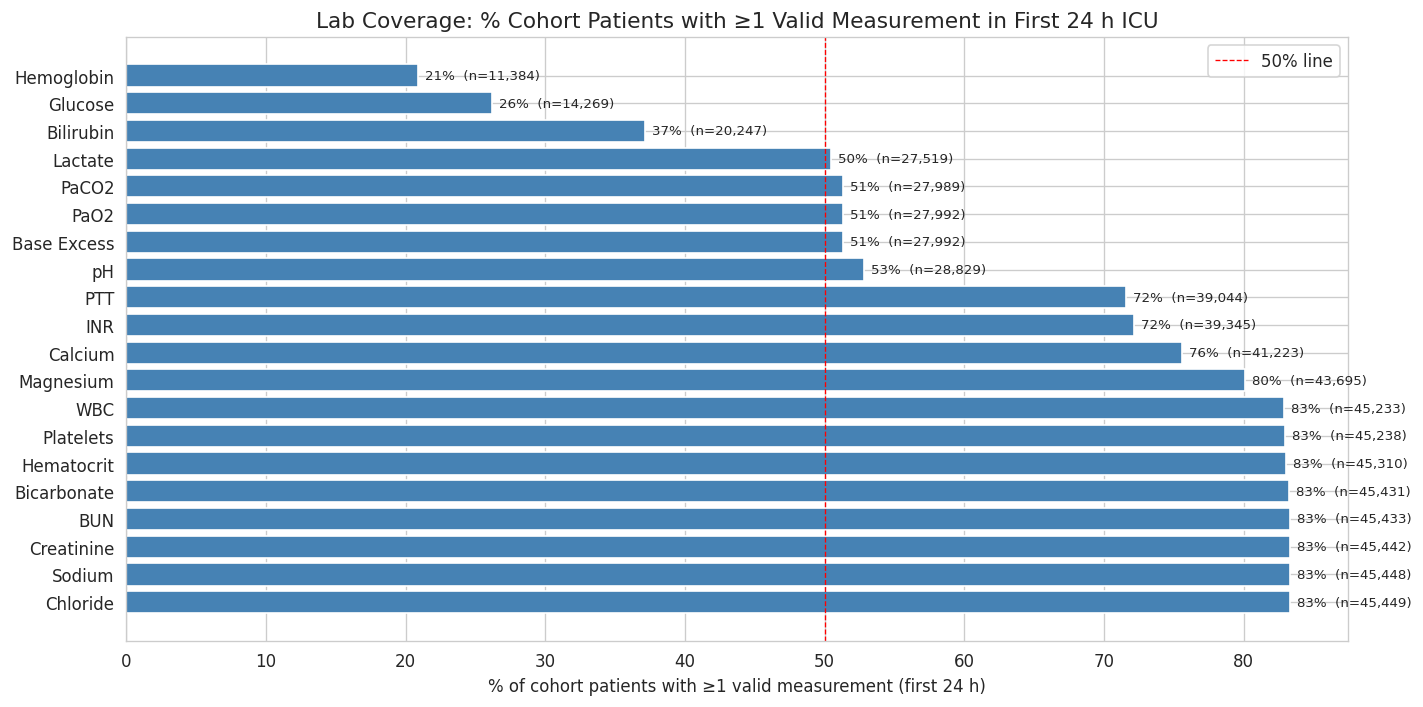

   lab_name  n_patients  pct_covered
   Chloride       45449       83.315
     Sodium       45448       83.313
 Creatinine       45442       83.302
        BUN       45433       83.285
Bicarbonate       45431       83.282
 Hematocrit       45310       83.060
  Platelets       45238       82.928
        WBC       45233       82.919
  Magnesium       43695       80.099
    Calcium       41223       75.568
        INR       39345       72.125
        PTT       39044       71.573
         pH       28829       52.848
Base Excess       27992       51.313
       PaO2       27992       51.313
      PaCO2       27989       51.308
    Lactate       27519       50.446
  Bilirubin       20247       37.116
    Glucose       14269       26.157
 Hemoglobin       11384       20.869


In [14]:
valid_labs = labs.dropna(subset=["valuenum"])

coverage = (
    valid_labs.groupby("lab_name")["subject_id"]
    .nunique()
    .rename("n_patients")
    .reset_index()
)
coverage["pct_covered"] = coverage["n_patients"] / len(cohort) * 100
coverage = coverage.sort_values("pct_covered", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    coverage["lab_name"],
    coverage["pct_covered"],
    color="steelblue",
)
ax.set(xlabel="% of cohort patients with ≥1 valid measurement (first 24 h)",
       title="Lab Coverage: % Cohort Patients with ≥1 Valid Measurement in First 24 h ICU")
ax.axvline(50, color="red", linestyle="--", linewidth=0.8, label="50% line")
ax.legend()
for bar, row in zip(bars, coverage.itertuples()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row.pct_covered:.0f}%  (n={row.n_patients:,})",
            va="center", fontsize=8)
plt.tight_layout()
plt.show()
print(coverage.to_string(index=False))

---
## 11 · Value distribution plots (before vs after cleaning)

Spot-check distributions for two key labs to verify cleaning did not distort the data.

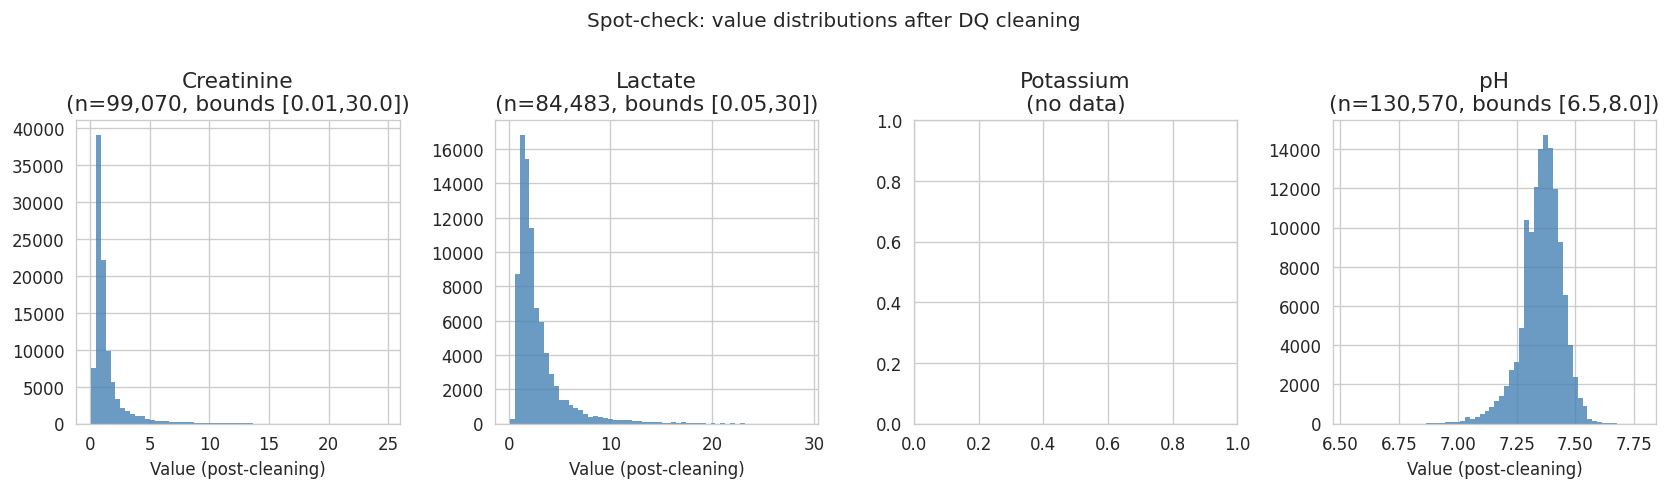

In [15]:
SPOT_LABS = ["Creatinine", "Lactate", "Potassium", "pH"]

fig, axes = plt.subplots(1, len(SPOT_LABS), figsize=(14, 4), sharey=False)

for ax, lab in zip(axes, SPOT_LABS):
    iid  = CANONICAL_IDS.get(lab)
    data = labs.loc[(labs["itemid"] == iid) & labs["valuenum"].notna(), "valuenum"]
    if data.empty:
        ax.set_title(f"{lab}\n(no data)")
        continue
    lo, hi = PHYS_BOUNDS[lab]
    ax.hist(data.clip(lo, hi), bins=60, color="steelblue", edgecolor="none", alpha=0.8)
    ax.set(title=f"{lab}\n(n={len(data):,}, bounds [{lo},{hi}])",
           xlabel="Value (post-cleaning)")

plt.suptitle("Spot-check: value distributions after DQ cleaning", y=1.01)
plt.tight_layout()
plt.show()

---
## 12 · Temporal resampling → 4-hour bins

ICU labs are ordered per shift (typically every 4–8 h).  
We aggregate to **4-hour bins** (6 bins × 24 h) — the same resolution used in the MIMIC-IV extract scripts and consistent with CLIF's `lab_collect_dttm` approach.

Bin assignment: `bin_4h = floor(hours_from_icu / 4)` → {0, 1, 2, 3, 4, 5}

Within each bin, **mean** is taken if multiple measurements exist (uncommon for most labs).  
A full patient × bin grid is created so that every patient has exactly 6 rows — this  
is required for temporal imputation strategies (forward fill, decay) in NB03.

In [16]:
# Assign 4-hour bin (clip at 5 for any measurement just at the boundary)
labs["bin_4h"] = (labs["hours_from_icu"] // 4).astype(int).clip(0, 5)

# Aggregate: MEAN per (patient, bin, lab) — labs are typically drawn once per
# 4h bin (duplicates are rare); mean is equivalent to the single value in most
# bins and smooths the occasional 2-value bin. Vitals (cell 37) use MEDIAN
# because they are charted every 1-5 min (dozens of points per bin) and a
# robust central tendency is more appropriate for that density.
labs_binned = (
    labs.dropna(subset=["valuenum"])
    .groupby(["subject_id", "stay_id", "bin_4h", "lab_name"], observed=True)["valuenum"]
    .mean()
    .reset_index()
)

# Pivot to wide format: one column per lab
labs_wide = labs_binned.pivot_table(
    index=["subject_id", "stay_id", "bin_4h"],
    columns="lab_name",
    values="valuenum",
    aggfunc="mean",    # already aggregated, but aggfunc required
)
labs_wide.columns.name = None
labs_wide = labs_wide.reset_index()

print(f"Wide-format shape: {labs_wide.shape}")
print(f"Lab columns: {[c for c in labs_wide.columns if c not in ['subject_id','stay_id','bin_4h']]}")

Wide-format shape: (155209, 23)
Lab columns: ['BUN', 'Base Excess', 'Bicarbonate', 'Bilirubin', 'Calcium', 'Chloride', 'Creatinine', 'Glucose', 'Hematocrit', 'Hemoglobin', 'INR', 'Lactate', 'Magnesium', 'PTT', 'PaCO2', 'PaO2', 'Platelets', 'Sodium', 'WBC', 'pH']


In [17]:
# Create full grid: every cohort patient × every bin (0–5)
# Using assign(key=1) cross-join for pandas < 1.2 compatibility
patient_df = cohort[["subject_id", "stay_id"]].assign(_key=1)
bins_df    = pd.DataFrame({"bin_4h": range(6), "_key": 1})
full_grid  = patient_df.merge(bins_df, on="_key").drop(columns="_key")

# Left-merge actual measurements onto full grid → NaN where no measurement
labs_raw = full_grid.merge(
    labs_wide,
    on=["subject_id", "stay_id", "bin_4h"],
    how="left",
)

LAB_COLS = [c for c in labs_raw.columns if c not in ["subject_id", "stay_id", "bin_4h"]]

print(f"labs_raw shape: {labs_raw.shape}")
print(f"  Rows   = {len(cohort):,} patients × 6 bins = {len(cohort)*6:,}  (actual: {len(labs_raw):,})")
print(f"  Lab cols: {len(LAB_COLS)}")

# Sparsity check
total_cells  = len(labs_raw) * len(LAB_COLS)
missing_cells = labs_raw[LAB_COLS].isna().sum().sum()
print(f"\nSparsity: {missing_cells/total_cells*100:.1f}% of lab-bin cells are NaN")
print("(Expected >90% — ICU labs ordered once per shift on average)")

labs_raw shape: (327306, 23)
  Rows   = 54,551 patients × 6 bins = 327,306  (actual: 327,306)
  Lab cols: 20

Sparsity: 76.3% of lab-bin cells are NaN
(Expected >90% — ICU labs ordered once per shift on average)


---
## 13 · Add `was_measured_<lab>` missingness indicators

Binary indicator columns encode the **missingness mechanism** as an explicit feature.  
These are included in **all** imputation strategies (NB03) as primary MNAR mitigation.  

> "More than 40% of the most predictive features were missingness indicators"  
> — Sharafoddini et al. (2019); confirmed by Singh et al. (2021): AUROC 0.737 → 0.814.

In [18]:
for col in LAB_COLS:
    labs_raw[f"was_measured_{col}"] = labs_raw[col].notna().astype("int8")

INDICATOR_COLS = [f"was_measured_{c}" for c in LAB_COLS]

print(f"Added {len(INDICATOR_COLS)} was_measured_* indicator columns")
print()
# Show average measurement rate per lab (across all 6 bins × all patients)
meas_rate = (
    labs_raw[INDICATOR_COLS]
    .mean()
    .rename(index=lambda x: x.replace("was_measured_", ""))
    .sort_values(ascending=False)
    * 100
)
print("Measurement rate per lab (% of patient-bin slots with a value):")
print(meas_rate.round(1).to_string())

Added 20 was_measured_* indicator columns

Measurement rate per lab (% of patient-bin slots with a value):
Hematocrit    32.700
Chloride      30.600
Sodium        29.700
Creatinine    29.500
BUN           29.400
Bicarbonate   29.300
Platelets     28.600
WBC           28.100
Magnesium     26.600
pH            25.600
Calcium       24.700
PaO2          23.800
Base Excess   23.700
PaCO2         23.700
PTT           21.700
INR           21.000
Lactate       19.600
Glucose       10.800
Bilirubin      9.100
Hemoglobin     4.900


---
## 14 · Save `labs_raw.parquet`

This is the **cleaned, resampled, not-yet-imputed** dataset.  
Format: wide, `(subject_id, stay_id, bin_4h)` × 24 lab columns + 24 indicator columns.  
NB03 will apply 8 imputation strategies to produce 8 separate Parquet outputs.

In [19]:
labs_raw.to_parquet(OUT_DIR / "labs_raw.parquet", index=False)

print(f"Saved: output/labs_raw.parquet")
print(f"  Shape: {labs_raw.shape[0]:,} rows × {labs_raw.shape[1]} cols")
print(f"  Patients: {labs_raw['subject_id'].nunique():,}")
print(f"  Bins per patient: 6 (0–5, each = 4 h)")
print(f"  Lab value cols: {len(LAB_COLS)}")
print(f"  Indicator cols: {len(INDICATOR_COLS)}")
print()
print("Dtypes:")
print(labs_raw.dtypes.to_string())

Saved: output/labs_raw.parquet
  Shape: 327,306 rows × 43 cols
  Patients: 54,551
  Bins per patient: 6 (0–5, each = 4 h)
  Lab value cols: 20
  Indicator cols: 20

Dtypes:
subject_id                    int64
stay_id                       int64
bin_4h                        int64
BUN                         float64
Base Excess                 float64
Bicarbonate                 float64
Bilirubin                   float64
Calcium                     float64
Chloride                    float64
Creatinine                  float64
Glucose                     float64
Hematocrit                  float64
Hemoglobin                  float64
INR                         float64
Lactate                     float64
Magnesium                   float64
PTT                         float64
PaCO2                       float64
PaO2                        float64
Platelets                   float64
Sodium                      float64
WBC                         float64
pH                          float64

---
## 15 · Extract vitals from chartevents (chunked I/O)

**Why chunked?** `chartevents.csv.gz` is 3.3 GB compressed (~330 M rows uncompressed) —
too large for a single `read_csv`. We stream 500 k rows at a time, pre-filtering to the
15 target itemids and cohort `stay_id`s in-loop. Expected runtime: **15–25 min**.

**Option B design:** ABP (invasive arterial line) and NIBP (non-invasive cuff) are kept as
**separate columns** with their own `was_measured_*` indicators. `was_measured_abp_*`
is itself a strong severity signal — its presence means the clinician deemed continuous
BP monitoring necessary.

**Ventilator-only columns (`fio2`, `peep`):** ~40 % of ICU stays are mechanically
ventilated. Absence = not on ventilator = informative MNAR. `was_measured_fio2` and
`was_measured_peep` are among the most clinically informative missingness indicators.

In [20]:
import time

# ICU cohort stay_ids for pre-filter (much faster than scanning all 330 M rows)
COHORT_STAY_IDS = set(cohort["stay_id"])

CHARTEVENTS_COLS = ["stay_id", "itemid", "charttime", "valuenum", "valueuom"]

print(f"Scanning chartevents.csv.gz  ({len(VITAL_TARGET_IDS)} itemids "
      f"| {len(COHORT_STAY_IDS):,} cohort stays)")
print("Expected: 15–25 min ...")

t0 = time.time()
proc_ce = sp.Popen(
    ["zcat", str(ICU / "chartevents.csv.gz")],
    stdout=sp.PIPE, stderr=sp.DEVNULL,
)

ce_chunks, n_ce_total = [], 0
for chunk in pd.read_csv(
    proc_ce.stdout,
    usecols=CHARTEVENTS_COLS,
    parse_dates=["charttime"],
    chunksize=500_000,
    low_memory=False,
    on_bad_lines="skip",
):
    n_ce_total += len(chunk)
    chunk["itemid"]  = pd.to_numeric(chunk["itemid"],  errors="coerce")
    chunk["stay_id"] = pd.to_numeric(chunk["stay_id"], errors="coerce")
    filt = chunk[
        chunk["itemid"].isin(VITAL_TARGET_IDS) &
        chunk["stay_id"].isin(COHORT_STAY_IDS)
    ].copy()
    if not filt.empty:
        ce_chunks.append(filt)

proc_ce.wait()
elapsed = time.time() - t0

ce = pd.concat(ce_chunks, ignore_index=True)
ce["charttime"] = pd.to_datetime(ce["charttime"], errors="coerce")
ce = ce.dropna(subset=["charttime", "valuenum"])
ce["valuenum"] = pd.to_numeric(ce["valuenum"], errors="coerce")
ce["stay_id"]  = ce["stay_id"].astype("int32")
ce["itemid"]   = ce["itemid"].astype("int32")
ce["vital_name"] = ce["itemid"].map(ITEMID_TO_VITAL)

print(f"\nScanned {n_ce_total:,} rows in {elapsed/60:.1f} min")
print(f"Retained {len(ce):,} rows after pre-filter")
print(f"Unique stays with vitals: {ce['stay_id'].nunique():,}")
print(f"\nRows per vital:")
print(ce["vital_name"].value_counts().to_string())

Scanning chartevents.csv.gz  (23 itemids | 54,551 cohort stays)
Expected: 15–25 min ...

Scanned 432,997,491 rows in 851.9 min
Retained 43,571,120 rows after pre-filter
Unique stays with vitals: 54,551

Rows per vital:
vital_name
resp_rate     6349466
heart_rate    5905131
spo2          5790762
nibp_sys      3479964
nibp_dia      3479201
nibp_mean     3472407
abp_sys       2549439
abp_dia       2549035
abp_mean      2271541
temp_c        1676105
gcs_eye       1553050
gcs_verbal    1550337
gcs_motor     1546491
fio2           792124
peep           606067


In [21]:
# Merge ICU intime -> 24h window filter
ce = ce.merge(cohort[["stay_id", "intime"]], on="stay_id", how="left")
ce["hours_from_intime"] = (ce["charttime"] - ce["intime"]).dt.total_seconds() / 3600
ce = ce[(ce["hours_from_intime"] >= 0) & (ce["hours_from_intime"] < 24)].copy()
print(f"After 24h ICU window filter: {len(ce):,} rows")

# Unit conversions
# Temperature: itemid 223761 is in °F -> convert to °C
mask_f = ce["itemid"] == 223761
ce.loc[mask_f, "valuenum"] = (ce.loc[mask_f, "valuenum"] - 32) * 5 / 9
print(f"  Temp °F → °C: {mask_f.sum():,} rows")

# FiO2: occasionally entered as fraction (0–1.5) -> convert to percentage
mask_fio2_frac = (ce["vital_name"] == "fio2") & (ce["valuenum"] < 2)
ce.loc[mask_fio2_frac, "valuenum"] *= 100
print(f"  FiO2 fraction → %: {mask_fio2_frac.sum():,} rows")

# Physiological outlier removal
n_pre_outlier = ce["valuenum"].notna().sum()
vital_outlier_report = []
for vname, (lo, hi) in VITAL_PHYS_BOUNDS.items():
    mask_vname = ce["vital_name"] == vname
    mask_out   = mask_vname & ((ce["valuenum"] < lo) | (ce["valuenum"] > hi))
    n_out = mask_out.sum()
    ce.loc[mask_out, "valuenum"] = np.nan
    vital_outlier_report.append({"vital": vname, "outliers_nulled": n_out, "lo": lo, "hi": hi})

n_post_outlier = ce["valuenum"].notna().sum()
print(f"\nPhysiological outlier removal (vitals):")
vout_df = pd.DataFrame(vital_outlier_report)
print(vout_df[vout_df["outliers_nulled"] > 0].to_string(index=False))
print(f"  Total nulled: {n_pre_outlier - n_post_outlier:,}")
PROV["vital_outliers_nulled"] = int(n_pre_outlier - n_post_outlier)

# 4-hour binning + deduplication (median within bin)
ce = ce.dropna(subset=["valuenum"])
ce["bin_4h"] = (ce["hours_from_intime"] // 4).clip(0, 5).astype(int)

ce_dedup = (
    ce.groupby(["stay_id", "vital_name", "bin_4h"])["valuenum"]
    .median()
    .reset_index()
)
print(f"\nAfter 4h binning + median dedup: {len(ce_dedup):,} rows")

# Wide pivot
vitals_wide = ce_dedup.pivot_table(
    index=["stay_id", "bin_4h"],
    columns="vital_name",
    values="valuenum",
    aggfunc="median",
).reset_index()
vitals_wide.columns.name = None

# Full grid: all cohort stays × 6 bins
full_grid_v = (
    pd.DataFrame({"stay_id": list(COHORT_STAY_IDS)})
    .assign(key=1)
    .merge(pd.DataFrame({"bin_4h": range(6), "key": 1}), on="key")
    .drop(columns="key")
)
vitals_raw = full_grid_v.merge(vitals_wide, on=["stay_id", "bin_4h"], how="left")

# Ensure all expected vital columns are present (some may be all-NaN)
for vc in VITAL_COLS:
    if vc not in vitals_raw.columns:
        vitals_raw[vc] = np.nan

vital_value_cols = sorted([c for c in vitals_raw.columns if c not in ("stay_id", "bin_4h")])
vitals_raw = vitals_raw[["stay_id", "bin_4h"] + vital_value_cols]

# was_measured_* indicators
VITAL_IND_COLS = []
for vc in vital_value_cols:
    ind = f"was_measured_{vc}"
    vitals_raw[ind] = vitals_raw[vc].notna().astype("int8")
    VITAL_IND_COLS.append(ind)

vitals_raw["stay_id"] = vitals_raw["stay_id"].astype("int32")
vitals_raw["bin_4h"]  = vitals_raw["bin_4h"].astype("int8")
vitals_raw = vitals_raw.sort_values(["stay_id", "bin_4h"]).reset_index(drop=True)

# Save
vitals_raw.to_parquet(OUT_DIR / "vitals_raw.parquet", index=False)

sparsity_v = vitals_raw[vital_value_cols].isna().mean().mean()
PROV["vital_rows"] = len(vitals_raw)
PROV["vital_cols"] = len(vital_value_cols)

print(f"\nSaved: output/vitals_raw.parquet")
print(f"  Shape         : {vitals_raw.shape[0]:,} rows × {vitals_raw.shape[1]} cols")
print(f"  Stays         : {vitals_raw['stay_id'].nunique():,}")
print(f"  Vital cols    : {len(vital_value_cols)}  |  Indicator cols: {len(VITAL_IND_COLS)}")
print(f"  Sparsity      : {sparsity_v:.1%}  (vitals measured much more frequently than labs)")
print(f"\n  Missing rate per vital:")
for vc in vital_value_cols:
    print(f"    {vc:<18} {vitals_raw[vc].isna().mean():.1%}")

After 24h ICU window filter: 11,370,939 rows
  Temp °F → °C: 333,747 rows
  FiO2 fraction → %: 350 rows

Physiological outlier removal (vitals):
     vital  outliers_nulled  lo  hi
heart_rate                4   0 300
   abp_sys               38   0 300
   abp_dia              114   0 200
  abp_mean             2242   0 200
  nibp_sys               12   0 300
  nibp_dia               94   0 200
 nibp_mean               93   0 200
 resp_rate              135   0  70
      spo2              332  50 100
    temp_c              440  25  45
      fio2             1019  21 100
      peep                4   0  30
  Total nulled: 4,527

After 4h binning + median dedup: 3,367,578 rows

Saved: output/vitals_raw.parquet
  Shape         : 327,306 rows × 32 cols
  Stays         : 54,551
  Vital cols    : 15  |  Indicator cols: 15
  Sparsity      : 31.4%  (vitals measured much more frequently than labs)

  Missing rate per vital:
    abp_dia            60.8%
    abp_mean           63.2%
    abp_sys  

---
## 15 · CLIF schema comparison

### Raw MIMIC-IV `labevents` (input)
Long format, itemid-centric, unit-inconsistent, duplicates present.

### Our cleaned output (`labs_raw.parquet`)
Wide format, lab-name-centric (CLIF `lab_name`), unit-standardised, deduplicated, 4-hour binned.

### Official CLIF `clif_labs.parquet` (reference)
Long format with `hospitalization_id`, `lab_collect_dttm`, `lab_name`, `lab_value_numeric`, `reference_unit`.

In [22]:
# Schema comparison table
schema_diff = pd.DataFrame([
    {
        "Dimension":     "Format",
        "Raw MIMIC-IV labevents": "Long (one row per measurement event)",
        "Our labs_raw.parquet":   "Wide (one row per patient × 4h bin)",
        "CLIF clif_labs.parquet": "Long (one row per measurement event)",
    },
    {
        "Dimension":     "Lab identifier",
        "Raw MIMIC-IV labevents": "itemid (numeric, opaque)",
        "Our labs_raw.parquet":   "Column name (human-readable lab_name)",
        "CLIF clif_labs.parquet": "lab_name + lab_category strings",
    },
    {
        "Dimension":     "Time representation",
        "Raw MIMIC-IV labevents": "Absolute charttime (UTC-shifted, de-identified)",
        "Our labs_raw.parquet":   "bin_4h: 0–5 (relative to ICU intime)",
        "CLIF clif_labs.parquet": "Absolute lab_collect_dttm (UTC)",
    },
    {
        "Dimension":     "Patient key",
        "Raw MIMIC-IV labevents": "subject_id + hadm_id",
        "Our labs_raw.parquet":   "subject_id + stay_id",
        "CLIF clif_labs.parquet": "hospitalization_id",
    },
    {
        "Dimension":     "Units",
        "Raw MIMIC-IV labevents": "Mixed (mg/dL and µmol/L for same itemid)",
        "Our labs_raw.parquet":   "Standardised per CLIF reference_unit",
        "CLIF clif_labs.parquet": "reference_unit column per row",
    },
    {
        "Dimension":     "Duplicates",
        "Raw MIMIC-IV labevents": "Present (amended results)",
        "Our labs_raw.parquet":   "Removed (keep highest labevent_id)",
        "CLIF clif_labs.parquet": "Handled in ETL",
    },
    {
        "Dimension":     "Outliers",
        "Raw MIMIC-IV labevents": "Present (impossible physiological values)",
        "Our labs_raw.parquet":   "Nulled (PHYS_BOUNDS per analyte)",
        "CLIF clif_labs.parquet": "Not explicitly documented",
    },
    {
        "Dimension":     "Missingness encoding",
        "Raw MIMIC-IV labevents": "Absent row (no explicit NaN)",
        "Our labs_raw.parquet":   "NaN + was_measured_<lab> binary indicator",
        "CLIF clif_labs.parquet": "Absent row (same as raw)",
    },
    {
        "Dimension":     "Scope",
        "Raw MIMIC-IV labevents": "All lab events, all patients, all time",
        "Our labs_raw.parquet":   "24 target labs, adult first ICU stays ≥24h, first 24h only",
        "CLIF clif_labs.parquet": "All labs, full ICU stay (with hospitalization mapping)",
    },
])

pd.set_option("display.max_colwidth", 80)
display(schema_diff)

,Dimension,Raw MIMIC-IV labevents,Our labs_raw.parquet,CLIF clif_labs.parquet
0,Format,Long (one row per measurement event),Wide (one row per patient × 4h bin),Long (one row per measurement event)
1,Lab identifier,"itemid (numeric, opaque)",Column name (human-readable lab_name),lab_name + lab_category strings
2,Time representation,"Absolute charttime (UTC-shifted, de-identified)",bin_4h: 0–5 (relative to ICU intime),Absolute lab_collect_dttm (UTC)
3,Patient key,subject_id + hadm_id,subject_id + stay_id,hospitalization_id
4,Units,Mixed (mg/dL and µmol/L for same itemid),Standardised per CLIF reference_unit,reference_unit column per row
5,Duplicates,Present (amended results),Removed (keep highest labevent_id),Handled in ETL
6,Outliers,Present (impossible physiological values),Nulled (PHYS_BOUNDS per analyte),Not explicitly documented
7,Missingness encoding,Absent row (no explicit NaN),NaN + was_measured_<lab> binary indicator,Absent row (same as raw)
8,Scope,"All lab events, all patients, all time","24 target labs, adult first ICU stays ≥24h, first 24h only","All labs, full ICU stay (with hospitalization mapping)"


In [23]:
# CLIF labs schema -- metadata only, no data loaded (clif_labs.parquet = 437 MB)
import pyarrow.parquet as pq

meta   = pq.read_metadata(CLIF_DIR / "clif_labs.parquet")
schema = pq.read_schema(CLIF_DIR / "clif_labs.parquet")

print(f"clif_labs.parquet  --  {meta.num_rows:,} rows x {meta.num_columns} columns")
print(f"Row groups: {meta.num_row_groups}  |  Serialized size: {meta.serialized_size:,} bytes")
print()
print("Column schema:")
for field in schema:
    print(f"  {field.name:<35} {str(field.type)}")

print()
print("Our labs_raw.parquet -- key columns (for comparison):")
display(labs_raw[["subject_id", "stay_id", "bin_4h"] + LAB_COLS[:6]].head(5))

clif_labs.parquet  --  48,386,986 rows x 14 columns
Row groups: 47  |  Serialized size: 79,022 bytes

Column schema:
  hospitalization_id                  string
  lab_order_dttm                      timestamp[us, tz=UTC]
  lab_collect_dttm                    timestamp[us, tz=UTC]
  lab_result_dttm                     timestamp[us, tz=UTC]
  lab_order_name                      null
  lab_order_category                  string
  lab_name                            string
  lab_category                        string
  lab_value                           string
  lab_value_numeric                   double
  reference_unit                      string
  lab_specimen_name                   null
  lab_specimen_category               null
  lab_loinc_code                      null

Our labs_raw.parquet -- key columns (for comparison):


,subject_id,stay_id,bin_4h,BUN,Base Excess,Bicarbonate,Bilirubin,Calcium,Chloride
0,10000690,37081114,0,NaN,NaN,NaN,NaN,NaN,NaN
1,10000690,37081114,1,21.000,NaN,26.000,NaN,9.000,104.000
2,10000690,37081114,2,NaN,NaN,NaN,NaN,NaN,NaN
3,10000690,37081114,3,NaN,NaN,NaN,NaN,NaN,NaN
4,10000690,37081114,4,NaN,NaN,NaN,NaN,NaN,NaN


---
## 16 · Provenance summary

Complete before/after count for every cleaning step applied in this notebook.

In [24]:
print("=" * 70)
print("  02_wrangle.ipynb — Provenance Summary")
print("=" * 70)
print()
print(f"{'Step':<45} {'Value':>12}")
print("-" * 60)
print(f"{'Cohort: patients selected (adult, ≥24h, first stay)':<45} {PROV['cohort_n']:>12,}")
print(f"{'  Hospital mortality rate':<45} {PROV['mortality_rate']*100:>11.1f}%")
print()
print(f"{'Lab rows after time filter (24h ICU window)':<45} {PROV['after_time_filter']:>12,}")
print()
print(f"{'DQ4 – Deduplicated rows removed':<45} {PROV['dedup_removed']:>12,}")
print(f"{'DQ5 – Censored values rescued (>/< parsing)':<45} {PROV['censored_rescued']:>12,}")
print(f"{'DQ2 – Rows unit-converted':<45} {PROV['unit_converted']:>12,}")
print(f"{'DQ3 – Outlier values nulled':<45} {PROV['outliers_nulled']:>12,}")
print()
print(f"{'Output: labs_raw.parquet rows':<45} {labs_raw.shape[0]:>12,}")
print(f"{'Output: labs_raw.parquet columns':<45} {labs_raw.shape[1]:>12,}")
print(f"{'  – lab value columns':<45} {len(LAB_COLS):>12,}")
print(f"{'  – was_measured indicator columns':<45} {len(INDICATOR_COLS):>12,}")
print(f"{'Output: cohort.parquet rows':<45} {len(cohort):>12,}")
print()
print(f"{'Sparsity: NaN lab-bin cells':<45}", end=" ")
total_cells   = len(labs_raw) * len(LAB_COLS)
missing_cells = labs_raw[LAB_COLS].isna().sum().sum()
print(f"{missing_cells/total_cells*100:>10.1f}%")
print("=" * 70)
print(f"{'Vitals: rows in vitals_raw.parquet':<45} {PROV.get('vital_rows', 'n/a'):>12,}")
print(f"{'Vitals: value columns':<45} {PROV.get('vital_cols', 'n/a'):>12,}")
print(f"{'Vitals: outlier values nulled':<45} {PROV.get('vital_outliers_nulled', 'n/a'):>12,}")
print(f"{'Vitals: rows in vitals_raw.parquet':<45} {PROV.get('vital_rows', 'n/a'):>12,}")
print(f"{'Vitals: value columns':<45} {PROV.get('vital_cols', 'n/a'):>12,}")
print(f"{'Vitals: outlier values nulled':<45} {PROV.get('vital_outliers_nulled', 'n/a'):>12,}")

  02_wrangle.ipynb — Provenance Summary

Step                                                 Value
------------------------------------------------------------
Cohort: patients selected (adult, ≥24h, first stay)       54,551
  Hospital mortality rate                            10.8%

Lab rows after time filter (24h ICU window)      1,863,118

DQ4 – Deduplicated rows removed                      1,010
DQ5 – Censored values rescued (>/< parsing)              4
DQ2 – Rows unit-converted                                0
DQ3 – Outlier values nulled                             87

Output: labs_raw.parquet rows                      327,306
Output: labs_raw.parquet columns                        43
  – lab value columns                                   20
  – was_measured indicator columns                      20
Output: cohort.parquet rows                         54,551

Sparsity: NaN lab-bin cells                         76.3%
Vitals: rows in vitals_raw.parquet                 327,306
Vita